In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import xgboost as xgb

Base sem quali

In [4]:
df_sem_quali = pd.read_csv(r"DATA\oficial.csv")
df_sem_quali.drop(columns=["posicao_quali_atual", "q1_atual", "q2_atual", "q3_atual", "dif_para_pole_atual"], inplace=True)
df_sem_quali.head()

,temporada_atual,rodada_atual,id_piloto_atual,target,id_circuito_atual,id_equipe_atual,grid_anterior,posicao_ultima_corrida,status,pontos_anterior_individual,...,media_ultimas_3_anterior,media_ultimas_5_anterior,qtde_abandonos_anterior,media_posicao_ganha_anterior,tendencia_desempenho,temp_ar_media,temp_pista_media,umidade_media,corrida_molhada,perc_voltas_chuva
0,2018,1,alonso,5,albert_park,mclaren,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
1,2018,1,bottas,8,albert_park,mercedes,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
2,2018,1,brendon_hartley,15,albert_park,toro_rosso,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
3,2018,1,ericsson,19,albert_park,sauber,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
4,2018,1,gasly,18,albert_park,toro_rosso,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5


In [5]:
df_sem_quali["posicao_equipe_anterior"] = pd.to_numeric(df_sem_quali["posicao_equipe_anterior"], errors="coerce")

df_sem_quali.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3590 entries, 0 to 3589
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   temporada_atual               3590 non-null   int64  
 1   rodada_atual                  3590 non-null   int64  
 2   id_piloto_atual               3590 non-null   object 
 3   target                        3590 non-null   int64  
 4   id_circuito_atual             3590 non-null   object 
 5   id_equipe_atual               3590 non-null   object 
 6   grid_anterior                 3381 non-null   float64
 7   posicao_ultima_corrida        3381 non-null   float64
 8   status                        3381 non-null   object 
 9   pontos_anterior_individual    3381 non-null   float64
 10  posicao_equipe_anterior       3404 non-null   float64
 11  pontos_equipe_anterior        3408 non-null   float64
 12  vitorias_equipe_anterior      3408 non-null   float64
 13  pon

In [6]:
df_sem_quali.describe()

,temporada_atual,rodada_atual,target,grid_anterior,posicao_ultima_corrida,pontos_anterior_individual,posicao_equipe_anterior,pontos_equipe_anterior,vitorias_equipe_anterior,pontos_anterior,...,media_ultimas_3_anterior,media_ultimas_5_anterior,qtde_abandonos_anterior,media_posicao_ganha_anterior,tendencia_desempenho,temp_ar_media,temp_pista_media,umidade_media,corrida_molhada,perc_voltas_chuva
count,3590.000000,3590.000000,3590.000000,3381.000000,3381.000000,3381.000000,3404.000000,3408.000000,3408.000000,3395.000000,...,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000
mean,2021.805850,11.122563,10.531476,10.264123,10.508429,5.074091,5.509694,112.372653,1.065728,56.228571,...,10.512197,10.511137,1.144624,-0.240200,0.001060,23.397187,35.273671,53.775253,0.033426,5.389861
std,2.415682,6.456837,5.789710,5.818943,5.786564,7.216828,2.881879,152.075410,2.686500,79.772816,...,4.662668,4.429625,1.284052,3.336187,1.471952,4.909411,9.075277,16.541314,0.179772,16.324197
min,2018.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,-18.000000,-6.800000,9.500000,15.210000,7.110000,0.000000,0.000000
25%,2020.000000,5.000000,6.000000,5.000000,5.000000,0.000000,3.000000,12.000000,0.000000,4.000000,...,7.000000,7.000000,0.000000,-2.000000,-0.730000,20.120000,28.970000,42.320000,0.000000,0.000000
50%,2022.000000,11.000000,11.000000,10.000000,11.000000,0.000000,6.000000,46.000000,0.000000,22.000000,...,11.000000,11.200000,1.000000,0.000000,0.000000,23.200000,35.230000,54.720000,0.000000,0.000000
75%,2024.000000,17.000000,16.000000,15.000000,16.000000,9.000000,8.000000,148.000000,0.000000,72.000000,...,14.330000,14.000000,2.000000,2.000000,0.740000,27.130000,42.030000,63.900000,0.000000,0.500000
max,2026.000000,24.000000,22.000000,22.000000,22.000000,26.000000,11.000000,822.000000,20.000000,549.000000,...,22.000000,22.000000,8.000000,14.000000,5.530000,36.570000,54.530000,96.440000,1.000000,98.000000


In [7]:
df_sem_quali.drop(columns=["id_piloto_atual"], inplace=True)

In [8]:
X = df_sem_quali.drop(columns=['target'])
y = df_sem_quali['target']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [11]:
onehotencoder = ColumnTransformer(transformers=[
    ('OneHot', OneHotEncoder(handle_unknown='ignore'), ['id_circuito_atual', 'id_equipe_atual', 'status'])
], remainder='passthrough')

In [12]:
X_train_transformed = onehotencoder.fit_transform(X_train)
X_test_transformed = onehotencoder.transform(X_test)

In [18]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 9],
    'min_child_weight': [1, 3 ,5],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10, 100],
    'reg_lambda': [0.5, 0.7, 1, 1.3]
}

xgb_model = xgb.XGBRegressor(random_state=42)

grid_search = RandomizedSearchCV(xgb_model, param_grid, cv=10, scoring="neg_mean_absolute_error", n_iter=100, n_jobs=-1, verbose=2, random_state=42)
grid_search.fit(X_train_transformed, y_train)

best_xgb = grid_search.best_estimator_

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor MAE:", -grid_search.best_score_) 

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Melhores parâmetros: {'subsample': 0.85, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Melhor MAE: 3.609336519241333


In [19]:
# Aprendi que esse dummy é meio que um modelo burro, e que pode ser usado para comparar com o modelo que eu treinei
# Se o resultado do meu modelo for inferior ao dummy, então meu modelo tá ruim e seria melhor eu mesmo chutar o resultado

# Aqui ele tá pra regressão
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train_transformed, y_train)
dummy_pred = dummy.predict(X_test_transformed)
print("MAE dummy:", mean_absolute_error(y_test, dummy_pred))

MAE dummy: 5.0715311023347125


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

predicoes = best_xgb.predict(X_test_transformed)

mae = mean_absolute_error(y_test, predicoes)
rmse = np.sqrt(mean_squared_error(y_test, predicoes))

print(f"MAE teste:  {mae:.4f}")
print(f"RMSE teste: {rmse:.4f}")

MAE teste:  3.7452
RMSE teste: 4.8118


Entendendo as features utilizadas

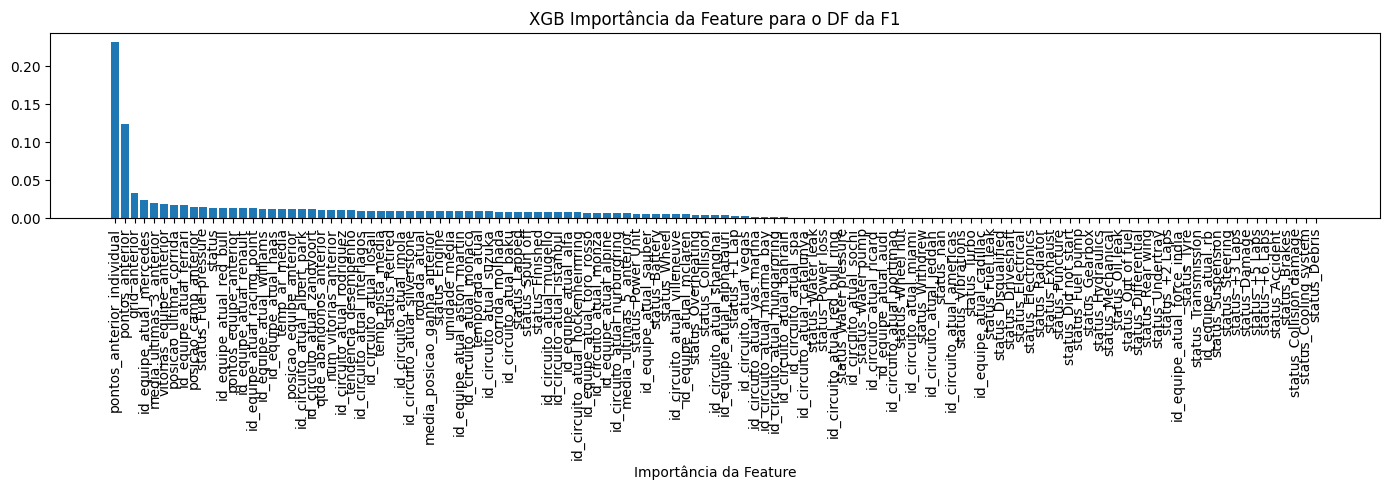

In [22]:
colunas_ohe = onehotencoder.named_transformers_['OneHot'].get_feature_names_out(['id_circuito_atual', 'id_equipe_atual', 'status'])
colunas_resto = [c for c in X.columns if c not in ['id_circuito_atual', 'id_equipe_atual']]
feature_names = list(colunas_ohe) + list(colunas_resto)

feature_importances = best_xgb.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(14, 5))
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align="center")
plt.xticks(range(len(feature_importances)), np.array(feature_names)[sorted_indices], rotation=90)
plt.xlabel("Importância da Feature")
plt.title("XGB Importância da Feature para o DF da F1")
plt.tight_layout()
plt.show()

In [24]:
import joblib

joblib.dump(best_xgb, r"models\fraud_detection_pipeline.pkl")
joblib.dump(onehotencoder, r"models\encoder_sem_quali.pkl")

['models\\encoder_sem_quali.pkl']